version plus organiser 

In [22]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

from ipywidgets import interact, SelectMultiple

load data

In [23]:
df = pd.read_csv("FINAL_DATASET_PREDICTION_CEjour.csv")

# ⚠️ garder si tu veux (mais pas optimal)
df.dropna(inplace=True)

print(df.shape)

(485151, 33)


SPLIT PUITS (FIXE)

In [24]:
wellnames = df["WELL"].dropna().unique().tolist()

np.random.seed(42)
np.random.shuffle(wellnames)

train_wells = wellnames[:80]
blind_wells = wellnames[80:89]

print("Train wells:", len(train_wells))
print("Blind wells:", len(blind_wells))

#sauvegarde 
with open("split.json", "w") as f:
    json.dump({"train": train_wells, "blind": blind_wells}, f)

Train wells: 80
Blind wells: 9


FEATURES / TARGET

In [25]:
features = [
    "WHP","WHT",
    "WHP_LAG_1","WHP_LAG_3","WHP_LAG_7",
    "WHT_LAG_1","WHT_LAG_3","WHT_LAG_7",
    "GAS_LAG_1","GAS_LAG_3","GAS_LAG_7",
    "WATER_LAG_1","WATER_LAG_3","WATER_LAG_7",
    "COND_LAG_1","COND_LAG_3","COND_LAG_7",
    "GAS_MEAN_3","GAS_MEAN_7",
    "WATER_MEAN_3","WATER_MEAN_7",
    "COND_MEAN_3","COND_MEAN_7",
    "DAY","MONTH","DAY_OF_WEEK"
]

targets = ["W_GAS","WATER","COND_VOL"]

DATASETS

In [26]:
# TRAIN
df_train = df[df["WELL"].isin(train_wells)].copy()

X = df_train[features]
y = df_train[targets]

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# BLIND
df_blind = df[df["WELL"].isin(blind_wells)].copy()
X_blind = df_blind[features]
y_blind = df_blind[targets]

FONCTION GÉNÉRIQUE MODEL

In [27]:
def run_model(name, model):

    print(f"\n===== {name} =====")

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # TRAIN
    pipe.fit(X_train, y_train)

    # PRED
    y_train_pred = pipe.predict(X_train)
    y_test_pred  = pipe.predict(X_test)
    y_blind_pred = pipe.predict(X_blind)

    # METRICS
    for i, target in enumerate(targets):
        print(f"{target}:")
        print(" Train R2:", r2_score(y_train.iloc[:, i], y_train_pred[:, i]))
        print(" Test  R2:", r2_score(y_test.iloc[:, i], y_test_pred[:, i]))
        print(" Blind R2:", r2_score(y_blind.iloc[:, i], y_blind_pred[:, i]))

    return pipe, y_train_pred, y_test_pred, y_blind_pred

MODELS

In [28]:
# Linear
lr_model, y_train_lr, y_test_lr, y_blind_lr = run_model(
    "LinearRegression", LinearRegression()
)



===== LinearRegression =====
W_GAS:
 Train R2: 0.9789800460926152
 Test  R2: 0.9784998419147625
 Blind R2: 0.974503075544996
WATER:
 Train R2: 0.9893825813181434
 Test  R2: 0.990135957684817
 Blind R2: 0.9563200147605212
COND_VOL:
 Train R2: 0.9836700410463118
 Test  R2: 0.9832193679544537
 Blind R2: 0.9830327308474517


In [29]:
# Random Forest
rf_model, y_train_rf, y_test_rf, y_blind_rf = run_model(
    "RandomForest",
    RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
)


===== RandomForest =====
W_GAS:
 Train R2: 0.9104574488832959
 Test  R2: 0.9059774030508673
 Blind R2: 0.86867180388053
WATER:
 Train R2: 0.9655545384621718
 Test  R2: 0.9603407341207608
 Blind R2: 0.828246047578354
COND_VOL:
 Train R2: 0.9877681693709722
 Test  R2: 0.9832999551439239
 Blind R2: 0.9810355994342993


In [30]:
# Decision Tree
dt_model, y_train_dt, y_test_dt, y_blind_dt = run_model(
    "DecisionTree", DecisionTreeRegressor(max_depth=10)
)


===== DecisionTree =====
W_GAS:
 Train R2: 0.9076681045338288
 Test  R2: 0.9007064529001516
 Blind R2: 0.8633796737422483
WATER:
 Train R2: 0.9592619860376904
 Test  R2: 0.9474142786627857
 Blind R2: 0.7817023393469258
COND_VOL:
 Train R2: 0.9861654626759888
 Test  R2: 0.97976271690794
 Blind R2: 0.9774209013281442


ANN (STRUCTURÉ)

In [31]:
def run_ann():

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    X_blind_s = scaler.transform(X_blind)

    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(3)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train_s, y_train.values, epochs=50, batch_size=512, verbose=0)

    y_train_pred = model.predict(X_train_s)
    y_test_pred  = model.predict(X_test_s)
    y_blind_pred = model.predict(X_blind_s)

    return model, y_train_pred, y_test_pred, y_blind_pred


ann_model, y_train_ann, y_test_ann, y_blind_ann = run_ann()

a:\pfe master\PEG_Python-master\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11057/11057 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


COMPARAISON

In [32]:
def evaluate_model(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    for i, target in enumerate(targets):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2  = r2_score(y_true.iloc[:, i], y_pred[:, i])

        print(f"{target} -> MAE: {mae:.4f} | R2: {r2:.4f}")


evaluate_model("LR", y_test, y_test_lr)
evaluate_model("DT", y_test, y_test_dt)
evaluate_model("RF", y_test, y_test_rf)
evaluate_model("ANN", y_test, y_test_ann)


===== LR =====
W_GAS -> MAE: 0.0088 | R2: 0.9785
WATER -> MAE: 0.0911 | R2: 0.9901
COND_VOL -> MAE: 1.5004 | R2: 0.9832

===== DT =====
W_GAS -> MAE: 0.0420 | R2: 0.9007
WATER -> MAE: 0.7609 | R2: 0.9474
COND_VOL -> MAE: 1.9526 | R2: 0.9798

===== RF =====
W_GAS -> MAE: 0.0415 | R2: 0.9060
WATER -> MAE: 0.7066 | R2: 0.9603
COND_VOL -> MAE: 1.6443 | R2: 0.9833

===== ANN =====
W_GAS -> MAE: 0.0179 | R2: 0.9737
WATER -> MAE: 0.2206 | R2: 0.9888
COND_VOL -> MAE: 1.5529 | R2: 0.9866


SAVE RESULTS

In [33]:
os.makedirs("results", exist_ok=True)

def save_pred(name, y_pred):
    df_save = df_blind.loc[X_blind.index].copy()

    df_save[f"GAS_{name}"]   = y_pred[:,0]
    df_save[f"WATER_{name}"] = y_pred[:,1]
    df_save[f"COND_{name}"]  = y_pred[:,2]

    df_save.to_csv(f"results/pred_{name}.csv", index=False)


save_pred("LR", y_blind_lr)
save_pred("DT", y_blind_dt)
save_pred("RF", y_blind_rf)
save_pred("ANN", y_blind_ann)

INTERACTIVE PLOT

In [34]:
df_plot = df_blind.loc[X_blind.index].copy()
df_plot["DATE"] = pd.to_datetime(df_plot["DATE"])

df_plot["LR"] = y_blind_lr[:,0]
df_plot["RF"] = y_blind_rf[:,0]
df_plot["ANN"] = y_blind_ann[:,0]
df_plot["DT"] = y_blind_dt[:,0]

def plot_wells(model="LR"):

    wells = df_plot["WELL"].unique()

    fig, ax = plt.subplots(3,2, figsize=(20,20))

    row = [0,0,1,1,2,2]
    col = [0,1,0,1,0,1]

    for i, well in enumerate(wells[:6]):

        dfp = df_plot[df_plot["WELL"] == well]

        ax[row[i], col[i]].scatter(dfp["DATE"], dfp["W_GAS"], label="Real")
        ax[row[i], col[i]].plot(dfp["DATE"], dfp[model], color="green", label=model)

        ax[row[i], col[i]].set_title(well)
        ax[row[i], col[i]].legend()

    plt.tight_layout()
    plt.show()


interact(plot_wells, model=["LR","RF","ANN","DT"])

interactive(children=(Dropdown(description='model', options=('LR', 'RF', 'ANN', 'DT'), value='LR'), Output()),…

<function __main__.plot_wells(model='LR')>

comparison table

In [35]:
def build_blind_comparison():

    results = []

    models = {
        "LR": y_blind_lr,
        "DT": y_blind_dt,
        "RF": y_blind_rf,
        "ANN": y_blind_ann
    }

    for model_name, y_pred in models.items():

        for i, target in enumerate(targets):

            mae = mean_absolute_error(y_blind.iloc[:, i], y_pred[:, i])
            r2  = r2_score(y_blind.iloc[:, i], y_pred[:, i])

            results.append({
                "Model": model_name,
                "Target": target,
                "MAE": mae,
                "R2": r2
            })

    return pd.DataFrame(results)

In [36]:
df_blind_compare = build_blind_comparison()
print(df_blind_compare)

   Model    Target       MAE        R2
0     LR     W_GAS  0.007244  0.974503
1     LR     WATER  0.204608  0.956320
2     LR  COND_VOL  1.200716  0.983033
3     DT     W_GAS  0.036757  0.863380
4     DT     WATER  1.120081  0.781702
5     DT  COND_VOL  1.730725  0.977421
6     RF     W_GAS  0.036665  0.868672
7     RF     WATER  0.999344  0.828246
8     RF  COND_VOL  1.507759  0.981036
9    ANN     W_GAS  0.018419  0.948658
10   ANN     WATER  0.316820  0.956336
11   ANN  COND_VOL  1.380676  0.986674


In [37]:
pivot_r2 = df_blind_compare.pivot(index="Model", columns="Target", values="R2")
print(pivot_r2)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.986674  0.956336  0.948658
DT      0.977421  0.781702  0.863380
LR      0.983033  0.956320  0.974503
RF      0.981036  0.828246  0.868672


selection of the best model

In [38]:
df_global = df_blind_compare.groupby("Model")["R2"].mean().reset_index()
df_global = df_global.sort_values("R2", ascending=False)

print(df_global)

best_model = df_global.iloc[0]["Model"]
print("Best model:", best_model)

  Model        R2
2    LR  0.971285
0   ANN  0.963889
3    RF  0.892651
1    DT  0.874168
Best model: LR


pearson correlation


In [40]:
def pearson_model(name, y_true, y_pred):

    results = []

    for i, target in enumerate(targets):

        corr = np.corrcoef(y_true.iloc[:, i], y_pred[:, i])[0,1]

        results.append({
            "Model": name,
            "Target": target,
            "Pearson": corr
        })

    return results

In [43]:
pearson_results = []

pearson_results += pearson_model("LR", y_blind, y_blind_lr)
pearson_results += pearson_model("DT", y_blind, y_blind_dt)
pearson_results += pearson_model("RF", y_blind, y_blind_rf)
pearson_results += pearson_model("ANN", y_blind, y_blind_ann)

df_pearson = pd.DataFrame(pearson_results)

#print(df_pearson)

In [42]:
pivot_pearson = df_pearson.pivot(index="Model", columns="Target", values="Pearson")
print(pivot_pearson)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.993419  0.978089  0.978523
DT      0.988646  0.884496  0.935143
LR      0.991481  0.977936  0.987171
RF      0.990494  0.910144  0.937537


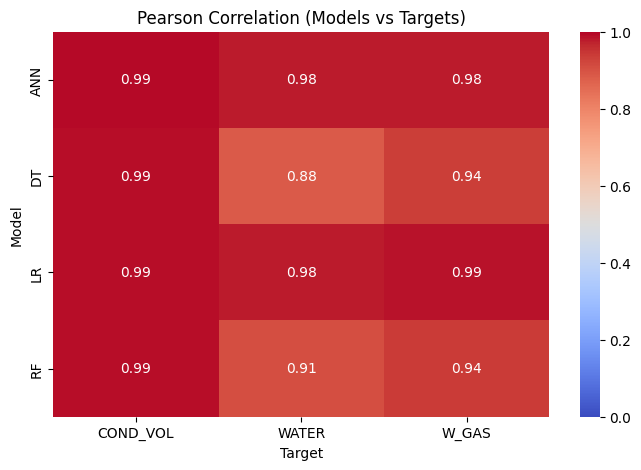

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(pivot_pearson, annot=True, cmap="coolwarm", vmin=0, vmax=1)

plt.title("Pearson Correlation (Models vs Targets)")
plt.show()